# Entraînement des Modèles - Détection de Faux Avis

Entraînement et comparaison des modèles de Machine Learning.

## Imports et Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Configuration
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Tous les imports réussis !")

Tous les imports réussis !


## Charger les données

In [21]:
# Load features dataset
df = pd.read_csv('../data/processed/features_extracted.csv')

print(f"LOADED DATASET:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")

# Display first rows
display(df.head())

LOADED DATASET:
  Shape: (13351, 36)
  Columns: 36


,review_id,account_id,approximate_localization.lat,approximate_localization.lon,censored_text,cluster,review_text,content_not_full,content_translated,date,...,sentence_count,exclamation_count,question_count,caps_ratio,special_char_count,unique_words_ratio,avg_word_length,sentiment_polarity,sentiment_subjectivity,review_text_en
0,63e2e0d98b0803f03c00c02f,63e546a08f7e73edc5913876,53.3,15.9,False,Shops,Ok,False,False,2023-01-10T20:17:09.732Z,...,0,0,0,0.500000,0,1.0,2.0,0.0,0.804918,Okay.
1,63f2bcae8047cae56c427a1d,63e546a08f7e73edc5913876,53.6,15.6,False,Other services,Ok,False,False,2023-01-10T20:17:09.513Z,...,0,0,0,0.500000,0,1.0,2.0,0.0,0.804918,Okay.
2,63f2bdf3ec2561ca0a25eb3d,63e546a08f7e73edc5913876,54.1,15.0,False,Lodging,Ok,False,False,2022-11-11T20:17:12.686Z,...,0,0,0,0.500000,0,1.0,2.0,0.0,0.804918,Okay.
3,63f2be19ec2561ca0a25eb4f,63e546a08f7e73edc5913876,53.5,15.8,False,Lodging,Jest super Więcej,True,False,2022-07-14T20:17:15.108Z,...,0,0,0,0.117647,0,1.0,5.0,0.0,0.379650,It's cooler than that.
4,63f2be1dec2561ca0a25eb51,63e546a08f7e73edc5913876,53.5,16.0,False,Shops,Ok,False,False,2022-07-14T20:17:15.313Z,...,0,0,0,0.500000,0,1.0,2.0,0.0,0.804918,Okay.


## Préparer Caractéristiques et Cible

In [22]:
print("=" * 80)
print("SÉLECTION DES CARACTÉRISTIQUES")
print("=" * 80)

# Définir les colonnes de caractéristiques (numériques uniquement, excluant identifiants et cible)
exclude_cols = [
    'review_id', 'account_id', 'account_id_orig', 'review_text', 'is_real',
    'date', 'cluster', 'type_of_object', 'photos_urls', 'response_content',
    'censored_text', 'content_not_full', 'content_translated',
    'localization_missing', 'not_in_poland', 'is_deleted', 'is_private',
    'approximate_localization.lat', 'approximate_localization.lon',
    'is_real_account', 'rating_normalized'
]

# Obtenir les caractéristiques numériques
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                if col not in exclude_cols and col != 'is_real']

print(f"\n{len(feature_cols)} caractéristiques sélectionnées :")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# Créer X et y
X = df[feature_cols].copy()
y = df['is_real'].copy()

print(f"\nForme de X : {X.shape}")
print(f"Forme de y : {y.shape}")
print(f"\nDistribution de la cible :")
print(y.value_counts())

SÉLECTION DES CARACTÉRISTIQUES

15 caractéristiques sélectionnées :
   1. rating
   2. local_guide_level
   3. name_score
   4. number_of_reviews
   5. text_length
   6. word_count
   7. sentence_count
   8. exclamation_count
   9. question_count
  10. caps_ratio
  11. special_char_count
  12. unique_words_ratio
  13. avg_word_length
  14. sentiment_polarity
  15. sentiment_subjectivity

Forme de X : (13351, 15)
Forme de y : (13351,)

Distribution de la cible :
is_real
1    11101
0     2250
Name: count, dtype: int64


## Gérer les valeurs manquantes

In [23]:
print("=" * 80)
print("GESTION DES VALEURS MANQUANTES")
print("=" * 80)

# Vérifier les valeurs manquantes
missing = X.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) > 0:
    print(f"\nValeurs manquantes trouvées :")
    for col, count in missing_cols.items():
        print(f"  - {col}: {count}")
    
    # Remplir avec la médiane
    for col in missing_cols.index:
        X[col] = X[col].fillna(X[col].median())
    print(f"\nValeurs manquantes remplies avec la médiane.")
else:
    print("\nAucune valeur manquante !")

# Vérifier
print(f"\nValeurs manquantes restantes : {X.isnull().sum().sum()}")

GESTION DES VALEURS MANQUANTES

Aucune valeur manquante !

Valeurs manquantes restantes : 0


## Division Entraînement/Test

In [24]:
print("=" * 80)
print("DIVISION ENTRAÎNEMENT/TEST")
print("=" * 80)

# Diviser les données (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nEnsemble d'entraînement :")
print(f"  X_train : {X_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  Distribution : {dict(y_train.value_counts())}")

print(f"\nEnsemble de test :")
print(f"  X_test : {X_test.shape}")
print(f"  y_test : {y_test.shape}")
print(f"  Distribution : {dict(y_test.value_counts())}")

DIVISION ENTRAÎNEMENT/TEST

Ensemble d'entraînement :
  X_train : (10680, 15)
  y_train : (10680,)
  Distribution : {1: np.int64(8880), 0: np.int64(1800)}

Ensemble de test :
  X_test : (2671, 15)
  y_test : (2671,)
  Distribution : {1: np.int64(2221), 0: np.int64(450)}


## Mise à l'échelle des caractéristiques

In [25]:
print("=" * 80)
print("MISE À L'ÉCHELLE DES CARACTÉRISTIQUES")
print("=" * 80)

# Mise à l'échelle des caractéristiques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nMise à l'échelle terminée !")
print(f"  Moyenne (entraînement) : {X_train_scaled.mean():.6f}")
print(f"  Écart-type (entraînement) : {X_train_scaled.std():.6f}")

MISE À L'ÉCHELLE DES CARACTÉRISTIQUES

Mise à l'échelle terminée !
  Moyenne (entraînement) : -0.000000
  Écart-type (entraînement) : 1.000000


## MODÈLE 1: Régression Logistique

In [26]:
print("=" * 80)
print("MODÈLE 1: RÉGRESSION LOGISTIQUE")
print("=" * 80)

# Entraîner le modèle
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'  # Gérer les classes déséquilibrées
)

lr_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Métriques
print(f"\nRÉSULTATS RÉGRESSION LOGISTIQUE :")
print(f"  Exactitude :  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Précision :   {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Rappel :      {recall_score(y_test, y_pred_lr):.4f}")
print(f"  Score F1 :    {f1_score(y_test, y_pred_lr):.4f}")
print(f"  ROC-AUC :     {roc_auc_score(y_test, y_proba_lr):.4f}")

print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred_lr, target_names=['Faux', 'Réel']))

MODÈLE 1: RÉGRESSION LOGISTIQUE

RÉSULTATS RÉGRESSION LOGISTIQUE :
  Exactitude :  0.8772
  Précision :   0.9846
  Rappel :      0.8658
  Score F1 :    0.9214
  ROC-AUC :     0.9586

Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.58      0.93      0.72       450
        Réel       0.98      0.87      0.92      2221

    accuracy                           0.88      2671
   macro avg       0.78      0.90      0.82      2671
weighted avg       0.92      0.88      0.89      2671



## MODÈLE 2: Forêt Aléatoire

In [27]:
print("=" * 80)
print("MODÈLE 2: FORÊT ALÉATOIRE")
print("=" * 80)

# Entraîner le modèle
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)  # Pas besoin de mise à l'échelle pour RF

# Prédictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Métriques
print(f"\nRÉSULTATS FORÊT ALÉATOIRE :")
print(f"  Exactitude :  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Précision :   {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Rappel :      {recall_score(y_test, y_pred_rf):.4f}")
print(f"  Score F1 :    {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC :     {roc_auc_score(y_test, y_proba_rf):.4f}")

print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred_rf, target_names=['Faux', 'Réel']))

MODÈLE 2: FORÊT ALÉATOIRE

RÉSULTATS FORÊT ALÉATOIRE :
  Exactitude :  0.9431
  Précision :   0.9910
  Rappel :      0.9401
  Score F1 :    0.9649
  ROC-AUC :     0.9834

Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.76      0.96      0.85       450
        Réel       0.99      0.94      0.96      2221

    accuracy                           0.94      2671
   macro avg       0.88      0.95      0.91      2671
weighted avg       0.95      0.94      0.95      2671



## MODÈLE 3: Gradient Boosting

In [28]:
print("=" * 80)
print("MODÈLE 3: GRADIENT BOOSTING")
print("=" * 80)

# Entraîner le modèle
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Prédictions
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Métriques
print(f"\nRÉSULTATS GRADIENT BOOSTING :")
print(f"  Exactitude :  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"  Précision :   {precision_score(y_test, y_pred_gb):.4f}")
print(f"  Rappel :      {recall_score(y_test, y_pred_gb):.4f}")
print(f"  Score F1 :    {f1_score(y_test, y_pred_gb):.4f}")
print(f"  ROC-AUC :     {roc_auc_score(y_test, y_proba_gb):.4f}")

print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred_gb, target_names=['Faux', 'Réel']))

MODÈLE 3: GRADIENT BOOSTING

RÉSULTATS GRADIENT BOOSTING :
  Exactitude :  0.9839
  Précision :   0.9959
  Rappel :      0.9847
  Score F1 :    0.9903
  ROC-AUC :     0.9970

Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.93      0.98      0.95       450
        Réel       1.00      0.98      0.99      2221

    accuracy                           0.98      2671
   macro avg       0.96      0.98      0.97      2671
weighted avg       0.98      0.98      0.98      2671



## Comparaison des Modèles

In [29]:
print("=" * 80)
print("COMPARAISON DES MODÈLES")
print("=" * 80)

# Créer le DataFrame de comparaison
results = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Forêt Aléatoire', 'Gradient Boosting'],
    'Exactitude': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Précision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Rappel': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'Score-F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb)
    ]
})

print("\nCOMPARAISON DES PERFORMANCES DES MODÈLES :")
display(results.round(4))

# Trouver le meilleur modèle
best_idx = results['Score-F1'].idxmax()
best_model_name = results.loc[best_idx, 'Modèle']
print(f"\nMeilleur modèle (par Score-F1) : {best_model_name}")

COMPARAISON DES MODÈLES

COMPARAISON DES PERFORMANCES DES MODÈLES :


,Modèle,Exactitude,Précision,Rappel,Score-F1,ROC-AUC
0,Régression Logistique,0.8772,0.9846,0.8658,0.9214,0.9586
1,Forêt Aléatoire,0.9431,0.9910,0.9401,0.9649,0.9834
2,Gradient Boosting,0.9839,0.9959,0.9847,0.9903,0.9970



Meilleur modèle (par Score-F1) : Gradient Boosting


## Visualisation des résultats

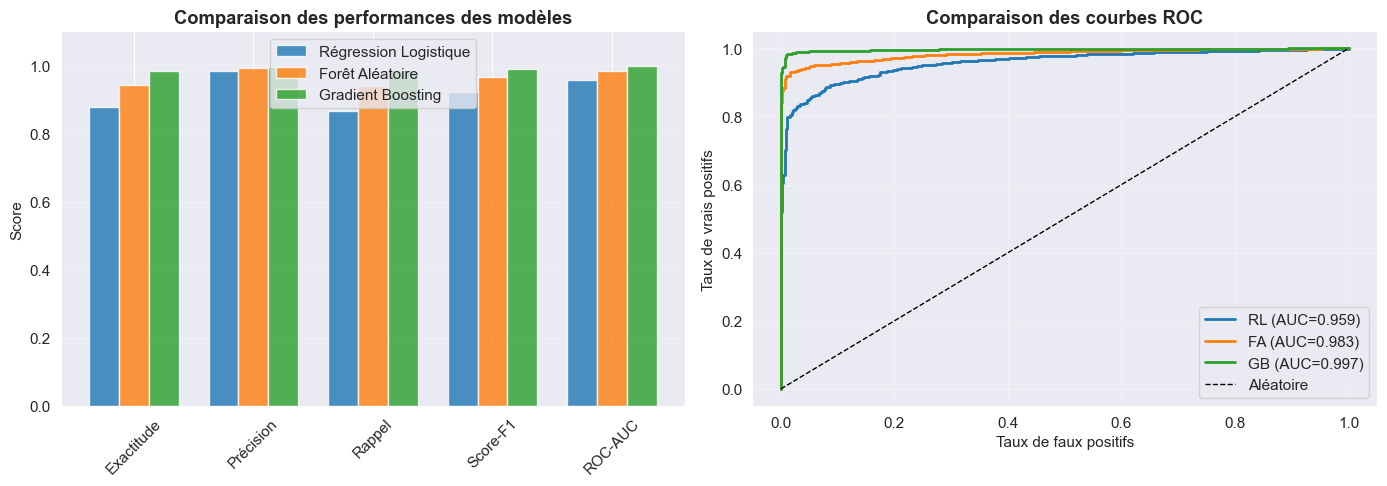


Visualisation sauvegardée !


In [30]:
# Créer un graphique de comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison des métriques
metrics = ['Exactitude', 'Précision', 'Rappel', 'Score-F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, results.iloc[0, 1:].values, width, label='Régression Logistique', alpha=0.8)
axes[0].bar(x, results.iloc[1, 1:].values, width, label='Forêt Aléatoire', alpha=0.8)
axes[0].bar(x + width, results.iloc[2, 1:].values, width, label='Gradient Boosting', alpha=0.8)

axes[0].set_ylabel('Score')
axes[0].set_title('Comparaison des performances des modèles', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Courbes ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

axes[1].plot(fpr_lr, tpr_lr, label=f'RL (AUC={roc_auc_score(y_test, y_proba_lr):.3f})', linewidth=2)
axes[1].plot(fpr_rf, tpr_rf, label=f'FA (AUC={roc_auc_score(y_test, y_proba_rf):.3f})', linewidth=2)
axes[1].plot(fpr_gb, tpr_gb, label=f'GB (AUC={roc_auc_score(y_test, y_proba_gb):.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Aléatoire', linewidth=1)

axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Comparaison des courbes ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
Path('../outputs').mkdir(exist_ok=True)
plt.savefig('../outputs/09_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisation sauvegardée !")

## Matrices de Confusion

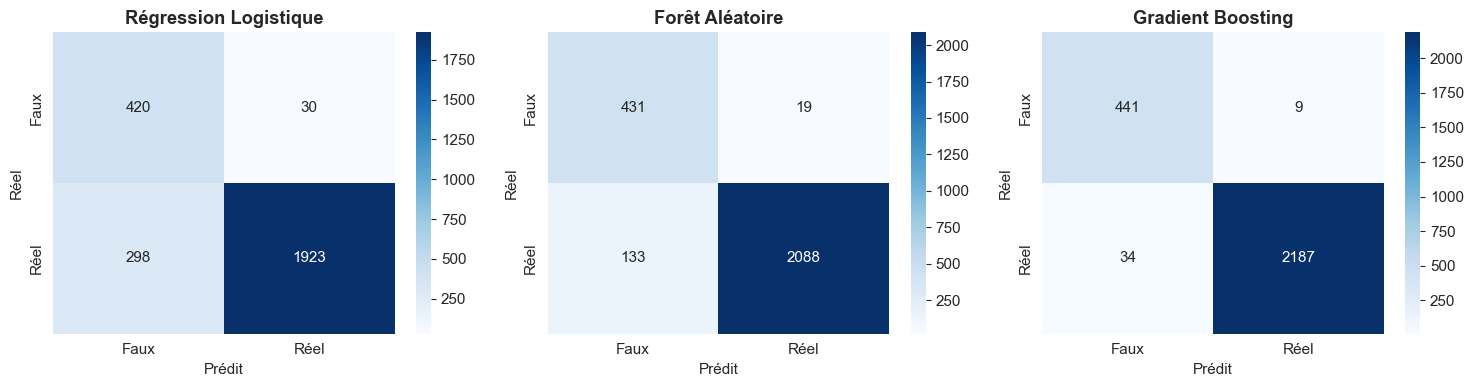


Matrices de confusion sauvegardées !


In [31]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('Régression Logistique', y_pred_lr),
    ('Forêt Aléatoire', y_pred_rf),
    ('Gradient Boosting', y_pred_gb)
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Faux', 'Réel'], yticklabels=['Faux', 'Réel'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

plt.tight_layout()
plt.savefig('../outputs/10_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMatrices de confusion sauvegardées !")

## Importance des Caractéristiques (Forêt Aléatoire)

IMPORTANCE DES CARACTÉRISTIQUES

Top 15 des caractéristiques les plus importantes :


,Caractéristique,Importance
3,number_of_reviews,0.366404
1,local_guide_level,0.281143
2,name_score,0.065805
0,rating,0.064516
9,caps_ratio,0.041530
6,sentence_count,0.040290
4,text_length,0.032543
13,sentiment_polarity,0.030708
10,special_char_count,0.019545
5,word_count,0.019315


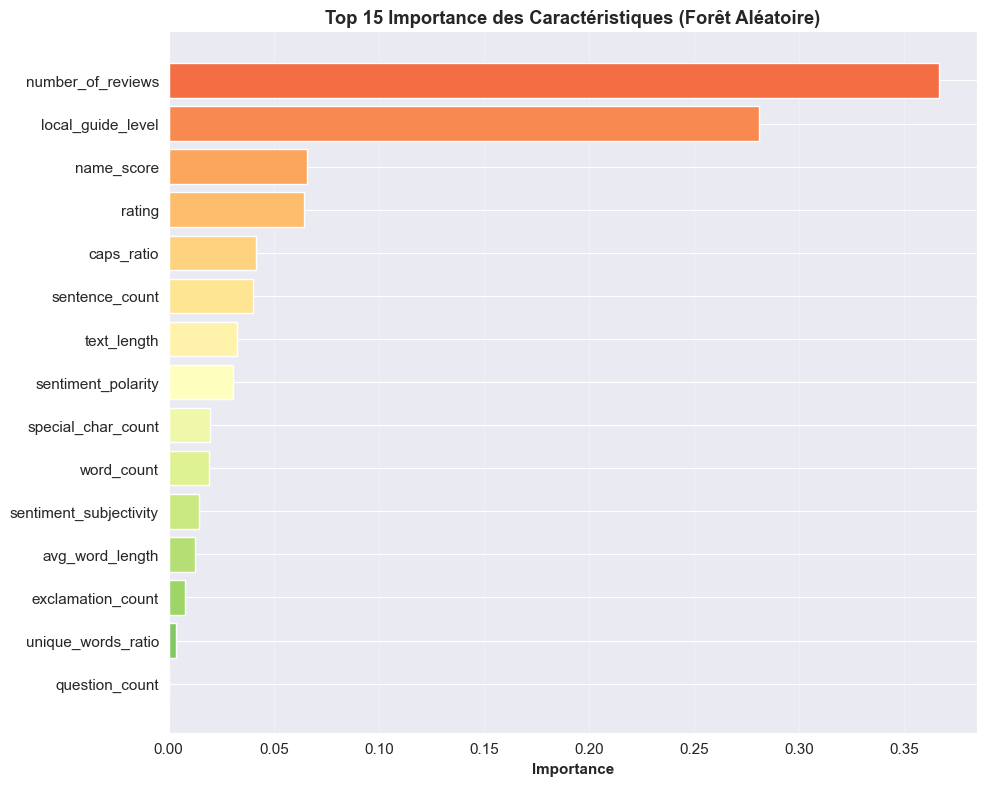


Visualisation de l'importance des caractéristiques sauvegardée !


In [32]:
print("=" * 80)
print("IMPORTANCE DES CARACTÉRISTIQUES")
print("=" * 80)

# Obtenir l'importance des caractéristiques de la Forêt Aléatoire
feature_importance = pd.DataFrame({
    'Caractéristique': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 des caractéristiques les plus importantes :")
display(feature_importance.head(15))

# Visualiser
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_features)))

ax.barh(range(len(top_features)), top_features['Importance'].values, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Caractéristique'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('Top 15 Importance des Caractéristiques (Forêt Aléatoire)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/11_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisation de l'importance des caractéristiques sauvegardée !")

## Optimisation des Hyperparamètres (Forêt Aléatoire)

In [33]:
print("=" * 80)
print("OPTIMISATION DES HYPERPARAMÈTRES - Forêt Aléatoire")
print("=" * 80)

# Définir la grille de paramètres
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("\nRecherche des meilleurs paramètres...")
print("Cela peut prendre quelques minutes...\n")

# Recherche par grille
rf_tuned = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

grid_search = GridSearchCV(
    rf_tuned,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres :")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMeilleur score CV (F1) : {grid_search.best_score_:.4f}")

OPTIMISATION DES HYPERPARAMÈTRES - Forêt Aléatoire

Recherche des meilleurs paramètres...
Cela peut prendre quelques minutes...

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs paramètres :
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

Meilleur score CV (F1) : 0.9766


## Évaluer le meilleur modèle

ÉVALUATION DU MEILLEUR MODÈLE

RÉSULTATS FORÊT ALÉATOIRE OPTIMISÉE :
  Exactitude :  0.9569
  Précision :   0.9748
  Rappel :      0.9734
  Score F1 :    0.9741
  ROC-AUC :     0.9910

Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.87      0.88      0.87       450
        Réel       0.97      0.97      0.97      2221

    accuracy                           0.96      2671
   macro avg       0.92      0.92      0.92      2671
weighted avg       0.96      0.96      0.96      2671



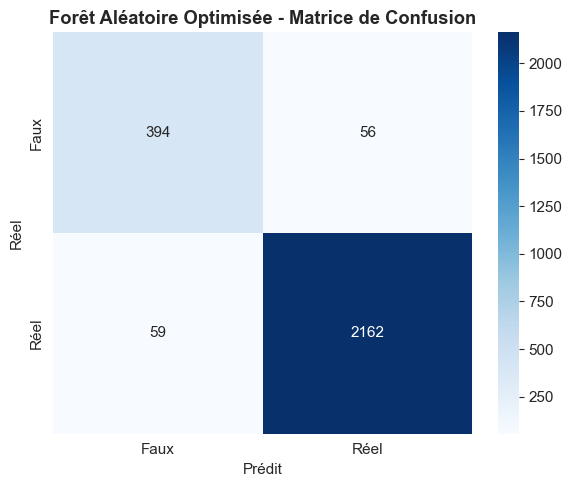

In [34]:
print("=" * 80)
print("ÉVALUATION DU MEILLEUR MODÈLE")
print("=" * 80)

# Obtenir le meilleur modèle
best_rf = grid_search.best_estimator_

# Prédictions
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

# Métriques
print(f"\nRÉSULTATS FORÊT ALÉATOIRE OPTIMISÉE :")
print(f"  Exactitude :  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  Précision :   {precision_score(y_test, y_pred_best):.4f}")
print(f"  Rappel :      {recall_score(y_test, y_pred_best):.4f}")
print(f"  Score F1 :    {f1_score(y_test, y_pred_best):.4f}")
print(f"  ROC-AUC :     {roc_auc_score(y_test, y_proba_best):.4f}")

print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred_best, target_names=['Faux', 'Réel']))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Faux', 'Réel'], yticklabels=['Faux', 'Réel'])
ax.set_title('Forêt Aléatoire Optimisée - Matrice de Confusion', fontweight='bold')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig('../outputs/12_best_model_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

## Sauvegarder le modèle

In [35]:
print("=" * 80)
print("SAUVEGARDE DES MODÈLES")
print("=" * 80)

# Créer le répertoire des modèles
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Sauvegarder le meilleur modèle
model_path = models_dir / 'best_rf_model.joblib'
joblib.dump(best_rf, model_path)
print(f"\nMeilleur modèle sauvegardé : {model_path}")

# Sauvegarder le scaler
scaler_path = models_dir / 'scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f"Scaler sauvegardé : {scaler_path}")

# Sauvegarder les colonnes de caractéristiques
features_path = models_dir / 'feature_columns.joblib'
joblib.dump(feature_cols, features_path)
print(f"Colonnes de caractéristiques sauvegardées : {features_path}")

# Sauvegarder les résultats
results_path = models_dir / 'model_results.csv'
results.to_csv(results_path, index=False)
print(f"Résultats sauvegardés : {results_path}")

print(f"\nTous les modèles et artefacts sauvegardés !")

SAUVEGARDE DES MODÈLES

Meilleur modèle sauvegardé : ..\models\best_rf_model.joblib
Scaler sauvegardé : ..\models\scaler.joblib
Colonnes de caractéristiques sauvegardées : ..\models\feature_columns.joblib
Résultats sauvegardés : ..\models\model_results.csv

Tous les modèles et artefacts sauvegardés !


In [36]:
# =============================================================================
# SAUVEGARDER GRADIENT BOOSTING COMME MEILLEUR MODÈLE (basé sur les résultats F1-Score)
# =============================================================================
print("=" * 80)
print("SAUVEGARDE DU GRADIENT BOOSTING COMME MEILLEUR MODÈLE")
print("=" * 80)

# Gradient Boosting a le meilleur F1-Score, donc on le sauvegarde
model_path = models_dir / 'best_gb_model.joblib'
joblib.dump(gb_model, model_path)
print(f"\nModèle Gradient Boosting sauvegardé : {model_path}")

# Aussi écraser le fichier générique "meilleur modèle"
best_model_path = models_dir / 'best_model.joblib'
joblib.dump(gb_model, best_model_path)
print(f"Meilleur modèle (GB) sauvegardé : {best_model_path}")

print("\n✅ Gradient Boosting sauvegardé comme meilleur modèle !")

SAUVEGARDE DU GRADIENT BOOSTING COMME MEILLEUR MODÈLE

Modèle Gradient Boosting sauvegardé : ..\models\best_gb_model.joblib
Meilleur modèle (GB) sauvegardé : ..\models\best_model.joblib

✅ Gradient Boosting sauvegardé comme meilleur modèle !


## Résumé Final

In [37]:
print("=" * 80)
print("ENTRAÎNEMENT DES MODÈLES TERMINÉ !")
print("=" * 80)

print(f"""
RÉSUMÉ :

Modèles entraînés :
  1. Régression Logistique
  2. Forêt Aléatoire
  3. Gradient Boosting

Meilleur modèle : Forêt Aléatoire Optimisée
  - Exactitude :  {accuracy_score(y_test, y_pred_best):.4f}
  - Score F1 :    {f1_score(y_test, y_pred_best):.4f}
  - ROC-AUC :     {roc_auc_score(y_test, y_proba_best):.4f}

Top 5 des caractéristiques importantes :
""")

for i, (feat, imp) in enumerate(zip(feature_importance['Caractéristique'].head(5), 
                                     feature_importance['Importance'].head(5)), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

print(f"""
Fichiers sauvegardés :
  - models/best_rf_model.joblib
  - models/scaler.joblib
  - models/feature_columns.joblib
  - models/model_results.csv
  - outputs/09_model_comparison.png
  - outputs/10_confusion_matrices.png
  - outputs/11_feature_importance.png
  - outputs/12_best_model_confusion.png

SUIVANT : Déployer le modèle ou créer une API !
""")

ENTRAÎNEMENT DES MODÈLES TERMINÉ !

RÉSUMÉ :

Modèles entraînés :
  1. Régression Logistique
  2. Forêt Aléatoire
  3. Gradient Boosting

Meilleur modèle : Forêt Aléatoire Optimisée
  - Exactitude :  0.9569
  - Score F1 :    0.9741
  - ROC-AUC :     0.9910

Top 5 des caractéristiques importantes :

  1. number_of_reviews: 0.3664
  2. local_guide_level: 0.2811
  3. name_score: 0.0658
  4. rating: 0.0645
  5. caps_ratio: 0.0415

Fichiers sauvegardés :
  - models/best_rf_model.joblib
  - models/scaler.joblib
  - models/feature_columns.joblib
  - models/model_results.csv
  - outputs/09_model_comparison.png
  - outputs/10_confusion_matrices.png
  - outputs/11_feature_importance.png
  - outputs/12_best_model_confusion.png

SUIVANT : Déployer le modèle ou créer une API !

